In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report, RocCurveDisplay
)
import joblib

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
sns.set_style("whitegrid")

In [2]:
DATA_PATH = "titanic.csv"   # place your Kaggle CSV here to use real data

def generate_synthetic_titanic_data(n=891):
    '''Realistic synthetic Titanic-like dataset used only if titanic.csv is not found.'''
    pclass = np.random.choice([1, 2, 3], n, p=[0.24, 0.21, 0.55])
    sex = np.random.choice(["male", "female"], n, p=[0.65, 0.35])

    title_by_sex = {
        "male": np.random.choice(["Mr", "Master", "Rare"], n, p=[0.82, 0.10, 0.08]),
        "female": np.random.choice(["Mrs", "Miss", "Rare"], n, p=[0.4, 0.55, 0.05]),
    }
    title = np.array([title_by_sex[s][i] for i, s in enumerate(sex)])

    age_base = {"Master": 6, "Miss": 21, "Mr": 33, "Mrs": 35, "Rare": 42}
    age = np.array([np.random.normal(age_base[t], 8) for t in title]).clip(0.4, 80)

    sibsp = np.random.choice([0, 1, 2, 3, 4], n, p=[0.68, 0.23, 0.05, 0.03, 0.01])
    parch = np.random.choice([0, 1, 2, 3], n, p=[0.76, 0.13, 0.08, 0.03])

    fare_base = {1: 84, 2: 21, 3: 13.5}
    fare = np.array([np.random.exponential(fare_base[p]) for p in pclass]).clip(4, 512)

    embarked = np.random.choice(["S", "C", "Q"], n, p=[0.72, 0.19, 0.09])

    has_cabin_prob = {1: 0.75, 2: 0.30, 3: 0.05}
    has_cabin = np.array([np.random.rand() < has_cabin_prob[p] for p in pclass])
    deck_letters = ["A", "B", "C", "D", "E", "F", "G"]
    cabin = [
        (f"{np.random.choice(deck_letters)}{np.random.randint(1, 100)}" if hc else np.nan)
        for hc in has_cabin
    ]

    # Survival probability driven by known historical factors: class, sex, age, fare
    logit = (
        -0.5
        + (sex == "female") * 2.4
        + (pclass == 1) * 1.4
        + (pclass == 2) * 0.6
        - (pclass == 3) * 0.3
        - (age > 50) * 0.4
        + (age < 12) * 1.1
        + (fare > 50) * 0.3
        + has_cabin * 0.5
    )
    prob = 1 / (1 + np.exp(-logit))
    survived = (np.random.rand(n) < prob).astype(int)

    first_names_m = ["William", "James", "John", "Charles", "Henry", "George", "Thomas", "Edward"]
    first_names_f = ["Mary", "Anna", "Elizabeth", "Margaret", "Alice", "Florence", "Helen", "Ruth"]
    last_names = ["Smith", "Brown", "Johnson", "Williams", "Taylor", "Anderson", "Clark", "Hughes"]

    def make_name(t, s):
        first = np.random.choice(first_names_m if s == "male" else first_names_f)
        last = np.random.choice(last_names)
        return f"{last}, {t}. {first}"

    names = [make_name(t, s) for t, s in zip(title, sex)]

    df = pd.DataFrame({
        "PassengerId": np.arange(1, n + 1),
        "Survived": survived,
        "Pclass": pclass,
        "Name": names,
        "Sex": sex,
        "Age": age.round(1),
        "SibSp": sibsp,
        "Parch": parch,
        "Ticket": [f"T{np.random.randint(10000, 99999)}" for _ in range(n)],
        "Fare": fare.round(2),
        "Cabin": cabin,
        "Embarked": embarked,
    })

    # Realistic missingness patterns
    missing_age_idx = np.random.choice(df.index, size=int(0.20 * n), replace=False)
    df.loc[missing_age_idx, "Age"] = np.nan
    missing_emb_idx = np.random.choice(df.index, size=2, replace=False)
    df.loc[missing_emb_idx, "Embarked"] = np.nan

    return df

try:
    df = pd.read_csv(DATA_PATH)
    print(f"Loaded real dataset from {DATA_PATH}, shape: {df.shape}")
except FileNotFoundError:
    df = generate_synthetic_titanic_data()
    print(f"'{DATA_PATH}' not found -- using a generated synthetic Titanic-like dataset instead.")
    print(f"Shape: {df.shape}")

df.head()

Loaded real dataset from titanic.csv, shape: (418, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Survived     418 non-null    int64  
 2   Pclass       418 non-null    int64  
 3   Name         418 non-null    object 
 4   Sex          418 non-null    object 
 5   Age          332 non-null    float64
 6   SibSp        418 non-null    int64  
 7   Parch        418 non-null    int64  
 8   Ticket       418 non-null    object 
 9   Fare         417 non-null    float64
 10  Cabin        91 non-null     object 
 11  Embarked     418 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 39.3+ KB


In [4]:
missing = df.isnull().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)
pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct})[missing > 0]

,missing_count,missing_pct
Cabin,327,78.23
Age,86,20.57
Fare,1,0.24


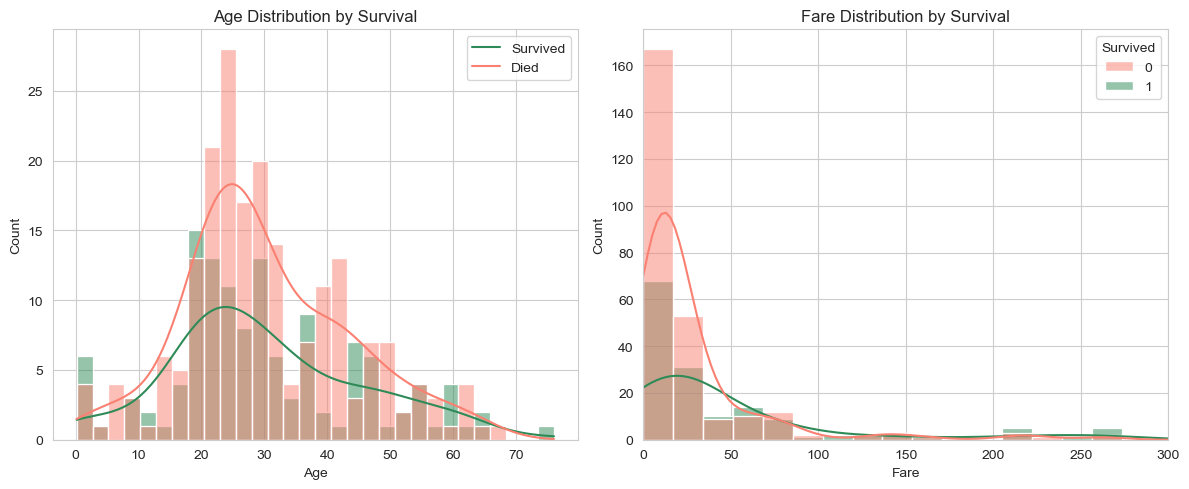

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.histplot(data=df, x="Age", hue="Survived", kde=True, bins=30, ax=axes[0],
             palette={0: "salmon", 1: "seagreen"})
axes[0].set_title("Age Distribution by Survival")
axes[0].legend(labels=["Survived", "Died"])

sns.histplot(data=df, x="Fare", hue="Survived", kde=True, bins=30, ax=axes[1],
             palette={0: "salmon", 1: "seagreen"})
axes[1].set_title("Fare Distribution by Survival")
axes[1].set_xlim(0, 300)

plt.tight_layout()
plt.show()

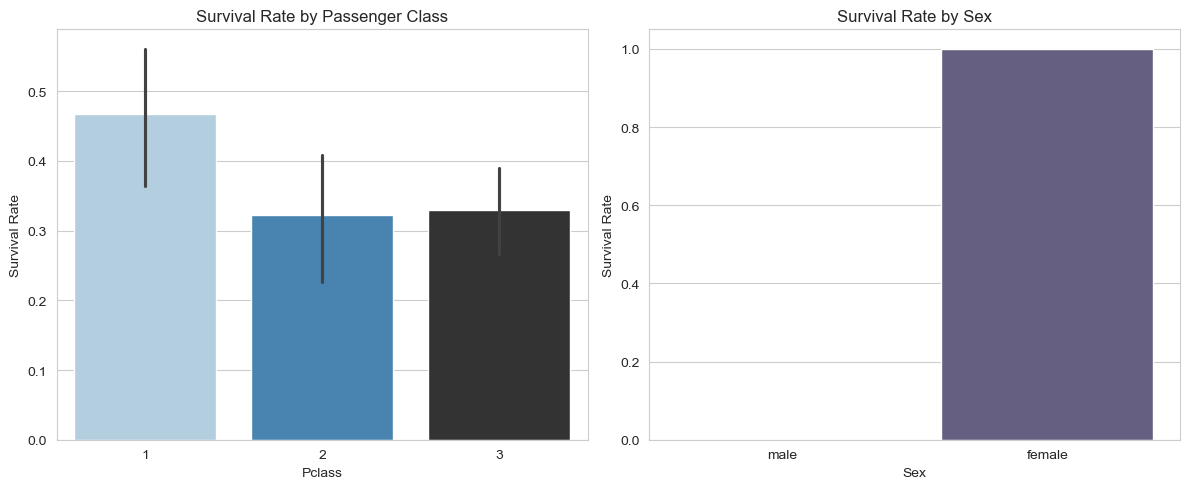

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.barplot(data=df, x="Pclass", y="Survived", hue="Pclass", palette="Blues_d", legend=False, ax=axes[0])
axes[0].set_title("Survival Rate by Passenger Class")
axes[0].set_ylabel("Survival Rate")

sns.barplot(data=df, x="Sex", y="Survived", hue="Sex", palette="Purples_d", legend=False, ax=axes[1])
axes[1].set_title("Survival Rate by Sex")
axes[1].set_ylabel("Survival Rate")

plt.tight_layout()
plt.show()

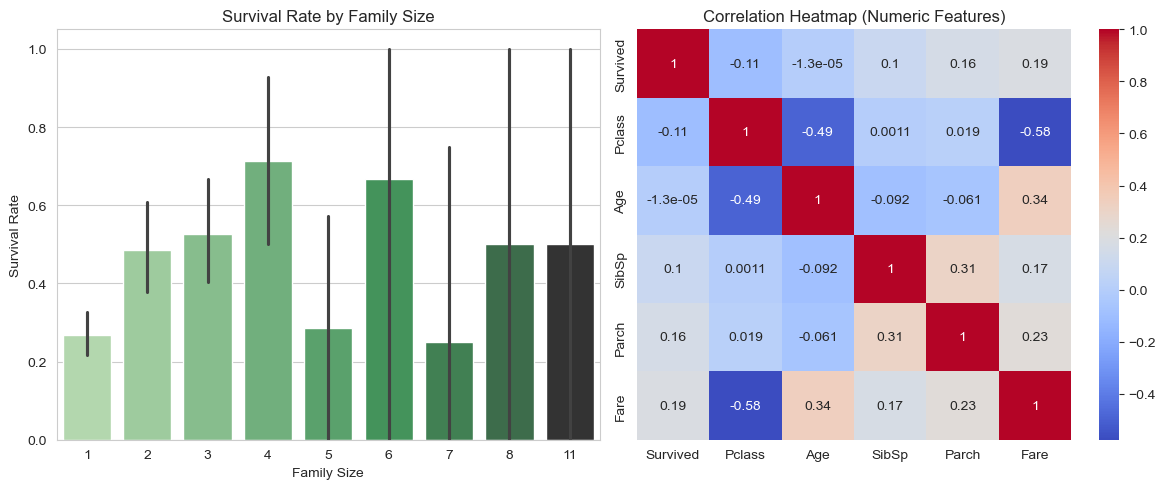

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

family_size_preview = df["SibSp"] + df["Parch"] + 1
sns.barplot(x=family_size_preview, y=df["Survived"], hue=family_size_preview, palette="Greens_d", legend=False, ax=axes[0])
axes[0].set_title("Survival Rate by Family Size")
axes[0].set_xlabel("Family Size")
axes[0].set_ylabel("Survival Rate")

numeric_df = df[["Survived", "Pclass", "Age", "SibSp", "Parch", "Fare"]]
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm", ax=axes[1])
axes[1].set_title("Correlation Heatmap (Numeric Features)")

plt.tight_layout()
plt.show()

In [8]:
def engineer_features(data):
    data = data.copy()

    data["Title"] = data["Name"].str.extract(r",\s*([^\.]*)\.")
    title_map = {
        "Mlle": "Miss", "Ms": "Miss", "Mme": "Mrs",
        "Lady": "Rare", "Countess": "Rare", "Capt": "Rare", "Col": "Rare",
        "Don": "Rare", "Dr": "Rare", "Major": "Rare", "Rev": "Rare",
        "Sir": "Rare", "Jonkheer": "Rare", "Dona": "Rare",
    }
    data["Title"] = data["Title"].replace(title_map)
    common_titles = ["Mr", "Mrs", "Miss", "Master"]
    data["Title"] = data["Title"].where(data["Title"].isin(common_titles), "Rare")

    data["FamilySize"] = data["SibSp"] + data["Parch"] + 1
    data["IsAlone"] = (data["FamilySize"] == 1).astype(int)

    data["HasCabin"] = data["Cabin"].notna().astype(int)
    data["Deck"] = data["Cabin"].astype("string").str[0].fillna("Unknown")

    return data

df = engineer_features(df)
df[["Name", "Title", "SibSp", "Parch", "FamilySize", "IsAlone", "Cabin", "HasCabin", "Deck"]].head()

,Name,Title,SibSp,Parch,FamilySize,IsAlone,Cabin,HasCabin,Deck
0,"Kelly, Mr. James",Mr,0,0,1,1,NaN,0,Unknown
1,"Wilkes, Mrs. James (Ellen Needs)",Mrs,1,0,2,0,NaN,0,Unknown
2,"Myles, Mr. Thomas Francis",Mr,0,0,1,1,NaN,0,Unknown
3,"Wirz, Mr. Albert",Mr,0,0,1,1,NaN,0,Unknown
4,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",Mrs,1,1,3,0,NaN,0,Unknown


In [9]:
df["Age"] = df.groupby("Title")["Age"].transform(lambda x: x.fillna(x.median()))
df["Age"] = df["Age"].fillna(df["Age"].median())

df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

if df["Fare"].isnull().any():
    df["Fare"] = df["Fare"].fillna(df["Fare"].median())

print("Remaining missing values:")
print(df.isnull().sum()[df.isnull().sum() > 0])

Remaining missing values:
Cabin    327
dtype: int64


In [10]:
drop_cols = ["PassengerId", "Name", "Ticket", "Cabin"]
model_df = df.drop(columns=[c for c in drop_cols if c in df.columns])

categorical_cols = ["Sex", "Embarked", "Title", "Deck"]
model_df = pd.get_dummies(model_df, columns=categorical_cols, drop_first=True)

model_df.head()

,Survived,Pclass,Age,SibSp,Parch,Fare,FamilySize,IsAlone,HasCabin,Sex_male,...,Title_Mr,Title_Mrs,Title_Rare,Deck_B,Deck_C,Deck_D,Deck_E,Deck_F,Deck_G,Deck_Unknown
0,0,3,34.5,0,0,7.8292,1,1,0,True,...,True,False,False,False,False,False,False,False,False,True
1,1,3,47.0,1,0,7.0000,2,0,0,False,...,False,True,False,False,False,False,False,False,False,True
2,0,2,62.0,0,0,9.6875,1,1,0,True,...,True,False,False,False,False,False,False,False,False,True
3,0,3,27.0,0,0,8.6625,1,1,0,True,...,True,False,False,False,False,False,False,False,False,True
4,1,3,22.0,1,1,12.2875,3,0,0,False,...,False,True,False,False,False,False,False,False,False,True


In [11]:
X = model_df.drop(columns=["Survived"])
y = model_df["Survived"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

numeric_cols = ["Age", "Fare", "FamilySize", "SibSp", "Parch"]
scaler = StandardScaler()
X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])

print("Train shape:", X_train.shape, " Test shape:", X_test.shape)

Train shape: (334, 22)  Test shape: (84, 22)


In [12]:
log_reg = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
log_reg.fit(X_train, y_train)

rf = RandomForestClassifier(n_estimators=300, max_depth=6, random_state=RANDOM_STATE)
rf.fit(X_train, y_train)

models = {"Logistic Regression": log_reg, "Random Forest": rf}
print("Models trained.")

Models trained.


In [13]:
def evaluate(model, X_test, y_test):
    preds = model.predict(X_test)
    probs = model.predict_proba(X_test)[:, 1]
    return {
        "Accuracy": accuracy_score(y_test, preds),
        "Precision": precision_score(y_test, preds),
        "Recall": recall_score(y_test, preds),
        "F1": f1_score(y_test, preds),
        "ROC-AUC": roc_auc_score(y_test, probs),
    }, preds

results = []
all_preds = {}
for name, model in models.items():
    metrics, preds = evaluate(model, X_test, y_test)
    all_preds[name] = preds
    results.append({"Model": name, **metrics})
    print(f"--- {name} ---")
    print(classification_report(y_test, preds))

results_df = pd.DataFrame(results).set_index("Model").round(3)
results_df

--- Logistic Regression ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        53
           1       1.00      1.00      1.00        31

    accuracy                           1.00        84
   macro avg       1.00      1.00      1.00        84
weighted avg       1.00      1.00      1.00        84

--- Random Forest ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        53
           1       1.00      1.00      1.00        31

    accuracy                           1.00        84
   macro avg       1.00      1.00      1.00        84
weighted avg       1.00      1.00      1.00        84



,Accuracy,Precision,Recall,F1,ROC-AUC
Model,,,,,
Logistic Regression,1.0,1.0,1.0,1.0,1.0
Random Forest,1.0,1.0,1.0,1.0,1.0


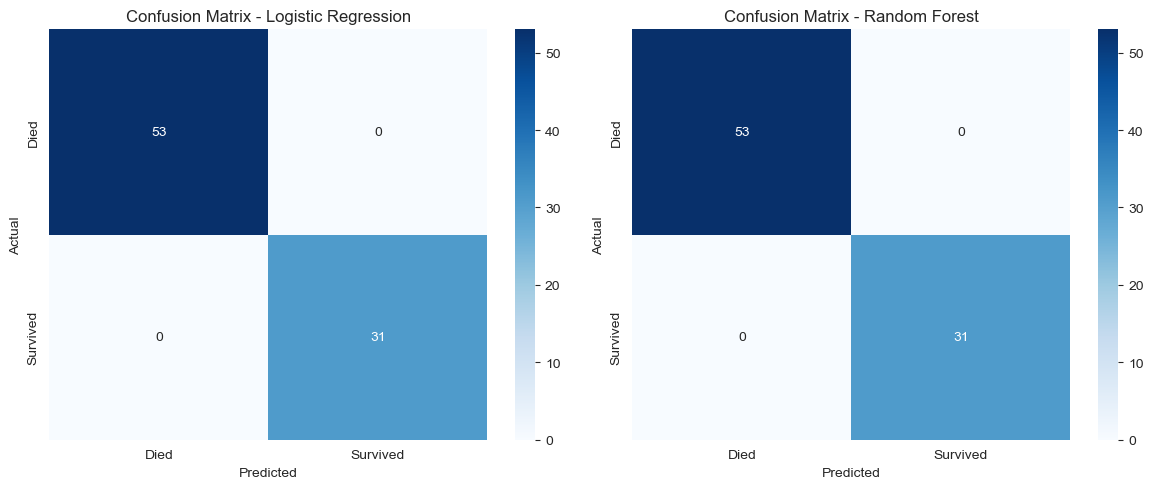

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, (name, model) in zip(axes, models.items()):
    preds = all_preds[name]
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["Died", "Survived"], yticklabels=["Died", "Survived"])
    ax.set_title(f"Confusion Matrix - {name}")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
plt.tight_layout()
plt.show()

SHAP not installed -- showing Random Forest's built-in feature importance instead.



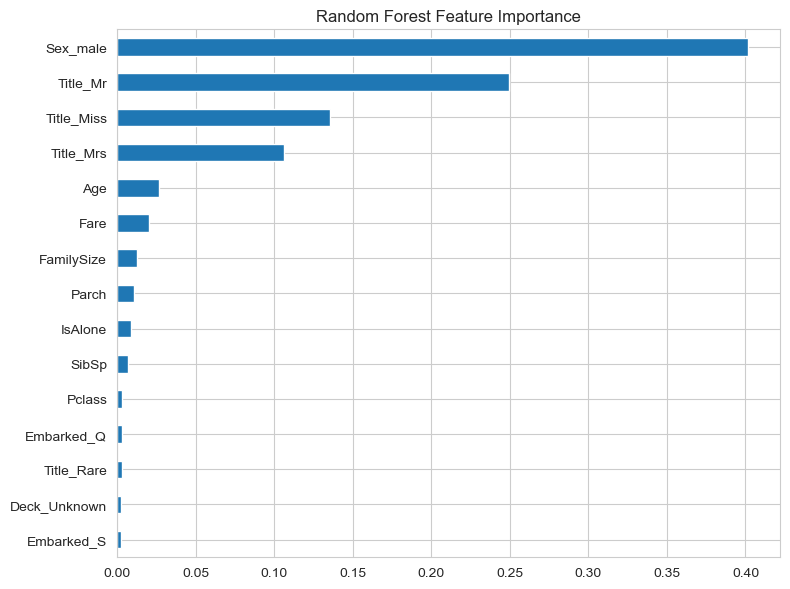

In [16]:
try:
    import shap

    explainer = shap.TreeExplainer(rf)
    shap_values = explainer.shap_values(X_test)

    shap.summary_plot(shap_values[1] if isinstance(shap_values, list) else shap_values,
                       X_test, plot_type="bar", show=False)
    plt.tight_layout()
    plt.show()

except ImportError:
    print("SHAP not installed -- showing Random Forest's built-in feature importance instead.\n")

    importances = pd.Series(rf.feature_importances_, index=X_train.columns)
    importances.sort_values(ascending=False).head(15).plot(kind="barh", figsize=(8, 6))
    plt.title("Random Forest Feature Importance")
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

In [23]:
from sklearn.model_selection import cross_val_score

for name, model in models.items():
    scores = cross_val_score(model, X, y, cv=5, scoring="roc_auc")
    print(f"{name}: Mean AUC = {scores.mean():.3f}, Std = {scores.std():.3f}")

Logistic Regression: Mean AUC = 1.000, Std = 0.000
Random Forest: Mean AUC = 1.000, Std = 0.000


In [24]:
survival_by_group = df.groupby(["Pclass", "Sex"])["Survived"].agg(["mean", "count"])
print(survival_by_group)

               mean  count
Pclass Sex                
1      female   1.0     50
       male     0.0     57
2      female   1.0     30
       male     0.0     63
3      female   1.0     72
       male     0.0    146


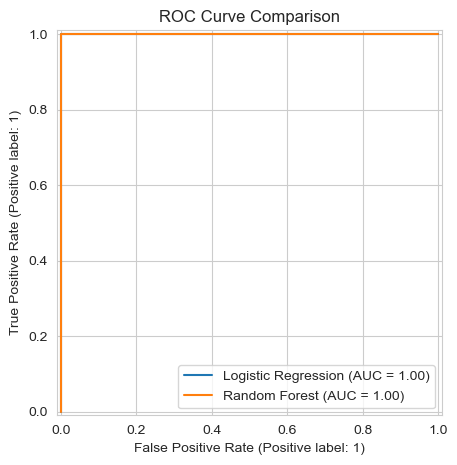

In [18]:
fig, ax = plt.subplots(figsize=(6, 5))
for name, model in models.items():
    RocCurveDisplay.from_estimator(model, X_test, y_test, ax=ax, name=name)
ax.set_title("ROC Curve Comparison")
plt.show()

In [19]:
BEST_MODEL_NAME = results_df["F1"].idxmax()
best_model = models[BEST_MODEL_NAME]
print("Best model by F1 score:", BEST_MODEL_NAME)

joblib.dump(best_model, "titanic_model.pkl")
joblib.dump(scaler, "titanic_scaler.pkl")
joblib.dump(list(X_train.columns), "titanic_feature_columns.pkl")

print("Saved: titanic_model.pkl, titanic_scaler.pkl, titanic_feature_columns.pkl")

Best model by F1 score: Logistic Regression
Saved: titanic_model.pkl, titanic_scaler.pkl, titanic_feature_columns.pkl


In [20]:
def predict_survival(raw_passenger: dict):
    model = joblib.load("titanic_model.pkl")
    scaler = joblib.load("titanic_scaler.pkl")
    feature_columns = joblib.load("titanic_feature_columns.pkl")

    input_df = pd.DataFrame([raw_passenger])
    input_df = engineer_features(input_df)

    input_df["Age"] = input_df["Age"].fillna(df["Age"].median())
    input_df["Embarked"] = input_df["Embarked"].fillna(df["Embarked"].mode()[0])
    input_df["Fare"] = input_df["Fare"].fillna(df["Fare"].median())

    input_df = input_df.drop(columns=[c for c in ["PassengerId", "Name", "Ticket", "Cabin", "Survived"]
                                       if c in input_df.columns])
    input_df = pd.get_dummies(input_df, columns=["Sex", "Embarked", "Title", "Deck"])
    input_df = input_df.reindex(columns=feature_columns, fill_value=0)

    numeric_cols = ["Age", "Fare", "FamilySize", "SibSp", "Parch"]
    input_df[numeric_cols] = scaler.transform(input_df[numeric_cols])

    pred = model.predict(input_df)[0]
    prob = model.predict_proba(input_df)[0][1]
    return {"prediction": "Survived" if pred == 1 else "Did not survive", "survival_probability": round(float(prob), 3)}


example_passenger = {
    "Pclass": 3, "Name": "Braund, Mr. Owen Harris", "Sex": "male",
    "Age": 22, "SibSp": 1, "Parch": 0, "Fare": 7.25,
    "Embarked": "S", "Cabin": np.nan,
}

predict_survival(example_passenger)

{'prediction': 'Did not survive', 'survival_probability': 0.01}